[Home](../../README.md)

### Model Evaluation

In this step all models are evaluated and compared to find the best model.

#### Step 1

Load the required dependencies.


In [3]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [4]:
# Step 2 - Safe pickle loading
with open("my_saved_model_v1.sav", "rb") as f:
    model_A = pickle.load(f)

(Optional) Load a second model if you want to do comparative testing

In [5]:
# Optional - Safe pickle loading
with open("my_saved_model_v2.sav", "rb") as f:
    model_B = pickle.load(f)

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [6]:
x_col = "duration_ms"
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['track_album_release_date'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

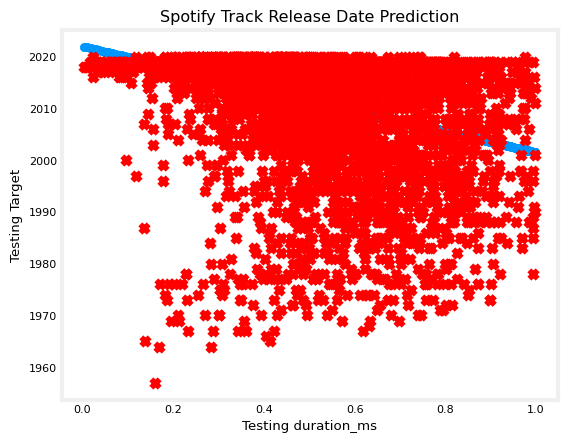

In [7]:
# Step 5 - Fix swapped axis labels
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker="x", c="r")
plt.title("Spotify Track Release Date Prediction")
plt.xlabel(f"Testing {x_col}")
plt.ylabel(f"Testing Target")
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [8]:
# Step 6 - fix label
test_score = model_A.score(x_test, y_test)
print(f"Testing data score: {test_score}")

Testing data score: 0.12123934849953377


In [9]:
# Step 6 - Model A score with R and R²
y_pred_A = model_A.predict(x_test)
r_A = np.corrcoef(y_test, y_pred_A.flatten())[0, 1]
r2_A = model_A.score(x_test, y_test)
print(f"R:  {r_A:.4f}")
print(f"R²: {r2_A:.4f}")

R:  0.3492
R²: 0.1212


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [10]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

      track_popularity  track_album_release_date  Predicted result      Loss
0             0.400489                      2014       2013.796564    0.0400
1             0.508935                      2008       2011.575501   12.8164
2             0.454605                      2019       2012.688214   39.8161
3             0.627046                      2015       2009.156490   34.1056
4             0.467513                      1999       2012.423861  180.0964
...                ...                       ...               ...       ...
5790          0.600611                      2005       2009.697891   22.0900
5791          0.616265                      2019       2009.377287   92.5444
5792          0.411018                      2019       2013.580924   29.3764
5793          0.329010                      2014       2015.260506    1.5876
5794          0.309839                      2019       2015.653149   11.2225

[5795 rows x 4 columns]
The cost or average loss of this model is 52.142449

You may want to do some manual predictions to understand your model.

In [11]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[2019.95082539]
[2001.51807911]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [12]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: 2021.9989083055623
Coefficient: [-20.48082919]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [13]:
# Step 9 - Safe pickle loading
with open("my_saved_model_v2.sav", "rb") as f:
    model_C = pickle.load(f)

In [14]:
mx_col = ["energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    # "key",
    # "song_mode",
    "duration_ms",]
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['track_album_release_date'])

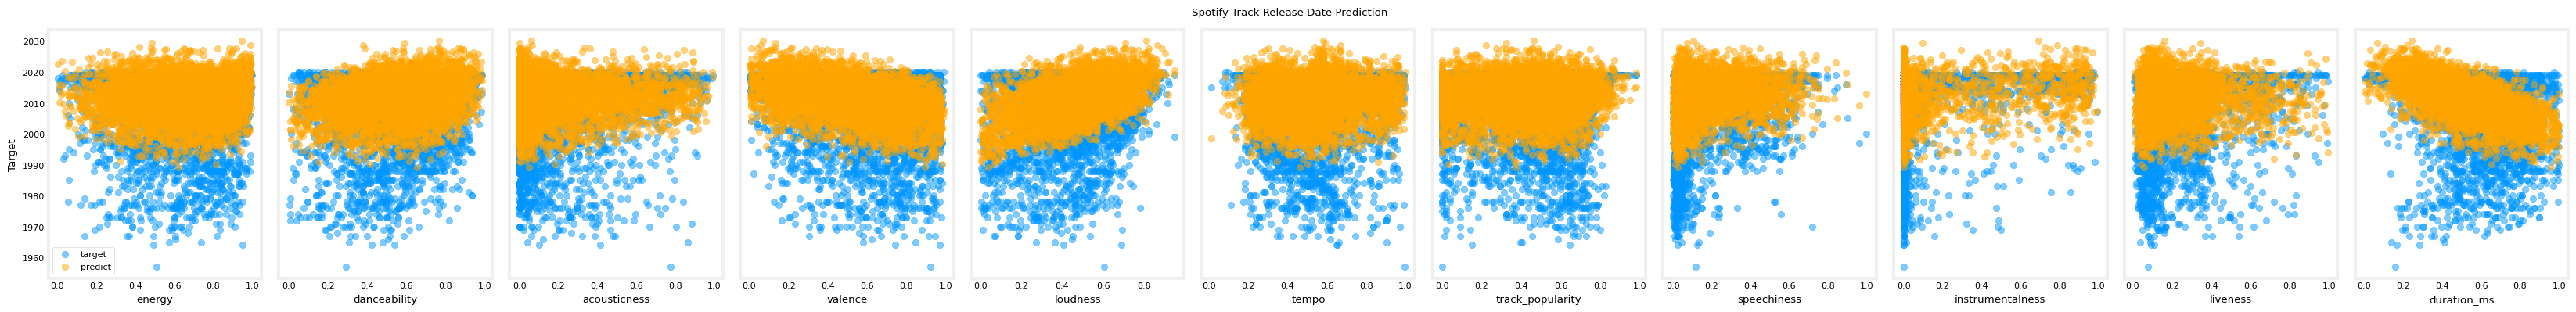

In [15]:
my_pred = model_C.predict(mx_test)

fig, ax = plt.subplots(1, len(mx_col), figsize=(len(mx_col) * 3, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:, i], my_test, label="target", alpha=0.5)
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:, i], my_pred, color="orange", label="predict", alpha=0.5)
ax[0].set_ylabel("Target")
ax[0].legend()
fig.suptitle("Spotify Track Release Date Prediction")
plt.tight_layout()
plt.show()

In [16]:
# Step 9 - fix label
test_score = model_C.score(mx_test, my_test)
print(f"Testing data score: {test_score}")

Testing data score: 0.3040054245487842


In [17]:
# Step 9 - Model C score with R and R²
r_C = np.corrcoef(my_test, model_C.predict(mx_test))[0, 1]
r2_C = model_C.score(mx_test, my_test)
print(f"R:  {r_C:.4f}")
print(f"R²: {r2_C:.4f}")

R:  0.5516
R²: 0.3040


In [18]:
print(model_C.predict([[0.1,0.1,0,1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1,0.5,1,0.5,1,0.5,1,0.5,1]]))

[2002.17887076]
[2018.18806943]


In [19]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 41.297209439171695
        energy  danceability  acousticness   valence  loudness     tempo  \
0     0.442543      0.306834      0.000036  0.632980  0.561189  0.264539   
1     0.622249      0.557880      0.037916  0.763984  0.345730  0.754077   
2     0.965770      0.352859      0.000184  0.148472  0.697931  0.411795   
3     0.973105      0.633194      0.000428  0.292992  0.741094  0.580760   
4     0.817848      0.482566      0.089989  0.597629  0.576051  0.611430   
...        ...           ...           ...       ...       ...       ...   
5790  0.556235      0.716876      0.506572  0.510293  0.495840  0.360326   
5791  0.486553      0.546722      0.025782  0.537326  0.433762  0.500584   
5792  0.776284      0.686192      0.224468  0.617384  0.568229  0.308556   
5793  0.910758      0.485356      0.001323  0.120399  0.679798  0.580452   
5794  0.326406      0.776848      0.299291  0.437513  0.652919  0.411758   

      track_popularity  sp

In [20]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: 2012.3923592368014
Coefficient: [ -8.7628803    9.75929833   2.36437953 -11.93786945  23.30066347
   2.32366757  -1.04852423   4.1249685    4.13124305  -0.52084561
 -16.06378099]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [21]:
with open("my_saved_model_v3.sav", "rb") as f:
    model_D = pickle.load(f)
with open("my_saved_poly_v3.pkl", "rb") as f:
    poly = pickle.load(f)

In [22]:
mx_col = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    # "key",
    # "song_mode",
    "duration_ms",
]
testing_data = pd.read_csv("2.4.1.testing_data.csv")
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data["track_album_release_date"])

In [23]:
poly_features = poly.transform(mx_test)

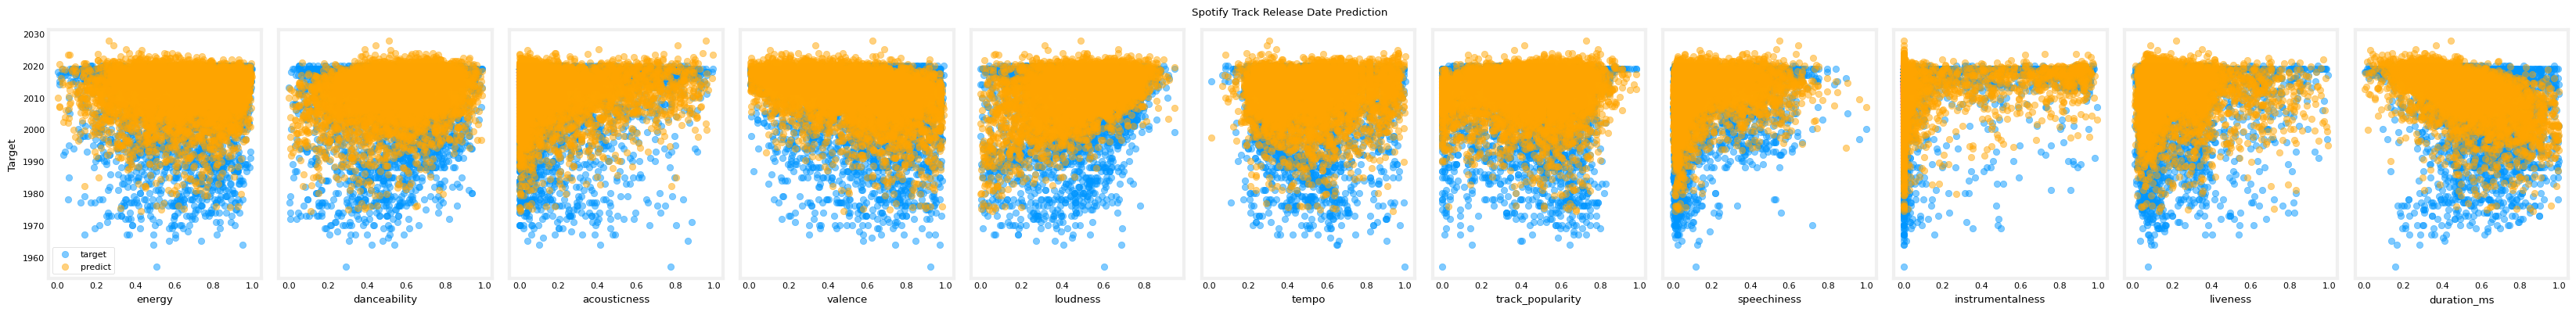

In [24]:
y_pred = model_D.predict(poly_features)

fig, ax = plt.subplots(1, len(mx_col), figsize=(len(mx_col) * 3, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:, i], my_test, label="target", alpha=0.5)
    ax[i].scatter(mx_test[:, i], y_pred, color="orange", label="predict", alpha=0.5)
    ax[i].set_xlabel(mx_col[i])
ax[0].set_ylabel("Target")
ax[0].legend()
fig.suptitle("Spotify Track Release Date Prediction")
plt.tight_layout()
plt.show()

In [25]:
test_score = model_D.score(poly_features, my_test)
print(f"Testing data score: {test_score}")

Testing data score: 0.3910122074296756


In [26]:
# Step 10 - Model D score with R and R²
r_D = np.corrcoef(my_test, model_D.predict(poly_features))[0, 1]
r2_D = model_D.score(poly_features, my_test)
print(f"R:  {r_D:.4f}")
print(f"R²: {r2_D:.4f}")

R:  0.6255
R²: 0.3910


In [27]:
sample = [[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]]  # 11 features
new_poly_feature = poly.transform(sample)
print(model_D.predict(new_poly_feature))

[2018.60855671]


In [28]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 36.13465368421052
        energy  danceability  acousticness   valence  loudness     tempo  \
0     0.442543      0.306834      0.000036  0.632980  0.561189  0.264539   
1     0.622249      0.557880      0.037916  0.763984  0.345730  0.754077   
2     0.965770      0.352859      0.000184  0.148472  0.697931  0.411795   
3     0.973105      0.633194      0.000428  0.292992  0.741094  0.580760   
4     0.817848      0.482566      0.089989  0.597629  0.576051  0.611430   
...        ...           ...           ...       ...       ...       ...   
5790  0.556235      0.716876      0.506572  0.510293  0.495840  0.360326   
5791  0.486553      0.546722      0.025782  0.537326  0.433762  0.500584   
5792  0.776284      0.686192      0.224468  0.617384  0.568229  0.308556   
5793  0.910758      0.485356      0.001323  0.120399  0.679798  0.580452   
5794  0.326406      0.776848      0.299291  0.437513  0.652919  0.411758   

      track_popularity  spe

In [29]:
print("Model Comparison")
print("-" * 35)
print(f"{'Model':<10} {'R':>10} {'R²':>10}")
print("-" * 35)
print(f"{'A (Simple)':<10} {r_A:>10.4f} {r2_A:>10.4f}")
print(f"{'C (Multi)':<10} {r_C:>10.4f} {r2_C:>10.4f}")
print(f"{'D (Poly)':<10} {r_D:>10.4f} {r2_D:>10.4f}")

Model Comparison
-----------------------------------
Model               R         R²
-----------------------------------
A (Simple)     0.3492     0.1212
C (Multi)      0.5516     0.3040
D (Poly)       0.6255     0.3910


#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.

In [30]:
# Step 11 - Load and evaluate Random Forest model
with open("my_saved_model_v4.sav", "rb") as f:
    model_E = pickle.load(f)

In [31]:
# Step 11 - Load test data for Random Forest
mx_col = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    # "key",
    # "song_mode",
    "duration_ms",
]
testing_data = pd.read_csv("2.4.1.testing_data.csv")
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data["track_album_release_date"])

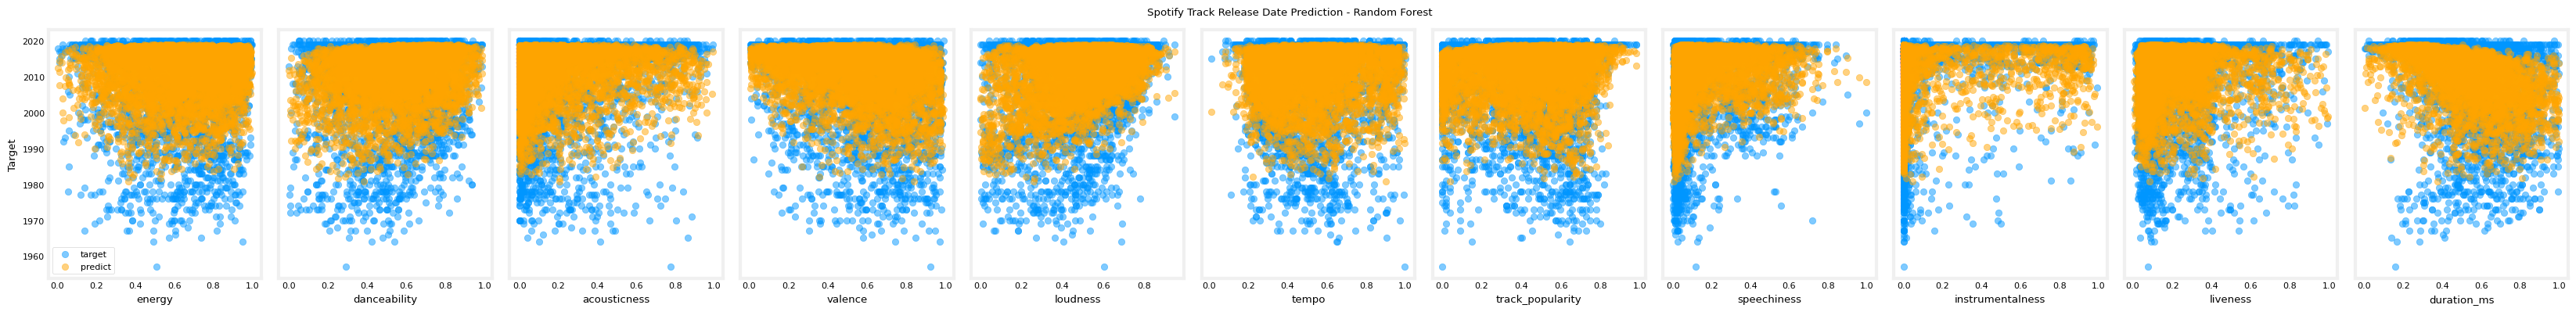

In [32]:
# Step 11 - Plot Random Forest predictions
y_pred_E = model_E.predict(mx_test)

fig, ax = plt.subplots(1, len(mx_col), figsize=(len(mx_col) * 3, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:, i], my_test, label="target", alpha=0.5)
    ax[i].scatter(mx_test[:, i], y_pred_E, color="orange", label="predict", alpha=0.5)
    ax[i].set_xlabel(mx_col[i])
ax[0].set_ylabel("Target")
ax[0].legend()
fig.suptitle("Spotify Track Release Date Prediction - Random Forest")
plt.tight_layout()
plt.show()

In [33]:
# Step 11 - Random Forest score with R and R²
r_E = np.corrcoef(my_test, y_pred_E)[0, 1]
r2_E = model_E.score(mx_test, my_test)
print(f"Testing data score: {r2_E}")
print(f"R:  {r_E:.4f}")
print(f"R²: {r2_E:.4f}")

Testing data score: 0.4227918003208282
R:  0.6508
R²: 0.4228


In [34]:
# Step 11 - Loss and cost table
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data["Target"] = my_test
data["Predicted result"] = y_pred_E
data["Loss"] = abs(y_pred_E.round(2) - my_test) ** 2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table["Loss"].sum()
print(f"The cost or average loss of this model is {cost}")
print(table)

The cost or average loss of this model is 34.24925490940466
        energy  danceability  acousticness   valence  loudness     tempo  \
0     0.442543      0.306834      0.000036  0.632980  0.561189  0.264539   
1     0.622249      0.557880      0.037916  0.763984  0.345730  0.754077   
2     0.965770      0.352859      0.000184  0.148472  0.697931  0.411795   
3     0.973105      0.633194      0.000428  0.292992  0.741094  0.580760   
4     0.817848      0.482566      0.089989  0.597629  0.576051  0.611430   
...        ...           ...           ...       ...       ...       ...   
5790  0.556235      0.716876      0.506572  0.510293  0.495840  0.360326   
5791  0.486553      0.546722      0.025782  0.537326  0.433762  0.500584   
5792  0.776284      0.686192      0.224468  0.617384  0.568229  0.308556   
5793  0.910758      0.485356      0.001323  0.120399  0.679798  0.580452   
5794  0.326406      0.776848      0.299291  0.437513  0.652919  0.411758   

      track_popularity  spe

In [35]:
# Step 11 - Updated model comparison including Random Forest
print("Model Comparison")
print("-" * 35)
print(f"{'Model':<10} {'R':>10} {'R²':>10}")
print("-" * 35)
print(f"{'A (Simple)':<10} {r_A:>10.4f} {r2_A:>10.4f}")
print(f"{'C (Multi)':<10} {r_C:>10.4f} {r2_C:>10.4f}")
print(f"{'D (Poly)':<10} {r_D:>10.4f} {r2_D:>10.4f}")
print(f"{'E (RF)':<10} {r_E:>10.4f} {r2_E:>10.4f}")

Model Comparison
-----------------------------------
Model               R         R²
-----------------------------------
A (Simple)     0.3492     0.1212
C (Multi)      0.5516     0.3040
D (Poly)       0.6255     0.3910
E (RF)         0.6508     0.4228


In [ ]:
# move model
model_filename = "my_saved_model_v4.sav"
with open("../../3.Operations/3.1.Deploy_Model/" + model_filename, "wb") as f:
    pickle.dump(model_E, f)